**Configuração do Ambiente e Imports**

Importa as bibliotecas essenciais para o projeto, incluindo manipulação de arquivos (os, shutil), visualização de dados (matplotlib) e a própria biblioteca do YOLO (ultralytics). Também verifica a disponibilidade e o status da GPU, essencial para acelerar o treinamento.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

%pip install ultralytics

import numpy as np
import pandas as pd
import os
import cv2
import matplotlib.pyplot as plt
%matplotlib inline
import shutil
import glob
import random
import yaml
from ultralytics import YOLO
import albumentations as A


Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 30.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**Preparação dos Dados (Descompactação)**

Define os caminhos dos arquivos e realiza a descompactação do dataset (arquivo .zip) diretamente no ambiente local da máquina virtual do Colab. Isso é crucial para garantir alta velocidade de leitura dos dados durante o treinamento, evitando a lentidão de ler diretamente do Google Drive.

In [ ]:
# Copiar o ZIP do Drive para o Colab
!cp "/content/drive/MyDrive/coffee_dataset.zip" /content/

# Criar a pasta dataset_novo e descompactar lá
!mkdir /content/dataset_novo
!unzip -q /content/coffee_dataset.zip -d /content/dataset_novo


**Análise Exploratória Inicial (Antes da Fusão)**

Varre os arquivos de anotação (labels) do conjunto de treino original para contar e visualizar a quantidade de exemplos por classe. Isso ajuda a identificar o desbalanceamento severo dos dados e a distribuição original das 5 classes (0 a 4).

In [ ]:
import os
print(os.listdir("/content"))

# Caminho base do dataset
ROOT = "/content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8"

print("Conteúdo do dataset:", os.listdir(ROOT))


['.config', 'dataset_novo', 'drive', 'coffee_dataset.zip', 'sample_data']
Conteúdo do dataset: ['test', 'train', 'data.yaml', 'valid', 'README.dataset.txt']


In [ ]:
import os

LABELS_PATH = "/content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/train/labels"

sample_files = os.listdir(LABELS_PATH)[:5]
for f in sample_files:
    with open(os.path.join(LABELS_PATH, f), 'r') as file:
        lines = file.readlines()
        print(f"{f}: {lines}")


IMG_20230824_110120_jpg.rf.319969fcee8bf19dbd2d1255a83ae6ae.txt: ['4 0.2841796875 0.4357096359375 0.2861328125 0.4278971359375 0.2893880203125 0.3992513015625 0.2897135421875 0.39208984375 0.2884114578125 0.3865559890625 0.2791341140625 0.3727213546875 0.2667643234375 0.3662109375 0.2517903640625 0.36328125 0.23876953125 0.3626302078125 0.22705078125 0.3629557296875 0.21533203125 0.3662109375 0.20556640625 0.3714192703125 0.197265625 0.3780924484375 0.1888020828125 0.4005533859375 0.1845703125 0.4080403640625 0.1819661453125 0.41748046875 0.1751302078125 0.42822265625 0.1731770828125 0.4386393234375 0.1748046875 0.44482421875 0.1798502609375 0.4527994796875 0.1863606765625 0.4557291671875 0.2552083328125 0.45751953125 0.25927734375 0.45703125 0.2664388015625 0.453125 0.2794596359375 0.4430338546875 0.2841796875 0.4357096359375\n', '4 0.1975911453125 0.3601888015625 0.1940104171875 0.3487955734375 0.1878255203125 0.33740234375 0.1687825515625 0.3111979171875 0.1482747390625 0.3014322921

**Definição da Estratégia de Fusão**

Define o coração da estratégia de engenharia de dados deste notebook: o mapa de fusão. Cria um dicionário (id_map) que instrui o código a transformar as classes originais 1 ("Muito Maduro") e 2 ("Maduro") em um único novo ID (1), e reajusta os IDs subsequentes para manter a sequência, resultando em apenas 4 classes finais.

In [ ]:
import os
import glob

# Pasta onde estão os labels
DATASET_DIR = ROOT
FOLDERS = ["train", "valid", "test"]

# Mapa de fusão:
# 0: seco -> 0
# 1: muito maduro -> 1
# 2: maduro -> 1
# 3: semi maduro -> 2
# 4: verde -> 3
id_map = {0:0, 1:1, 2:1, 3:2, 4:3}

count_modified = 0
for folder in FOLDERS:
    label_dir = os.path.join(DATASET_DIR, folder, "labels")
    if not os.path.exists(label_dir):
        continue

    txt_files = glob.glob(os.path.join(label_dir, "*.txt"))
    print(f"Processando pasta '{folder}' ({len(txt_files)} arquivos)...")

    for txt_file in txt_files:
        with open(txt_file, 'r') as f:
            lines = f.readlines()

        new_lines = []
        modified = False

        for line in lines:
            line = line.strip()
            if not line: # Ignora linhas completamente vazias
                new_lines.append("\n")
                continue

            parts = line.split()

            # Garantimos que a linha tem pelo menos o ID e duas coordenadas (3 partes)
            if len(parts) >= 3:
                try:
                    old_id = int(float(parts[0]))
                except ValueError:
                    # Se a primeira parte não é um ID válido, apenas mantém a linha
                    new_lines.append(line + "\n")
                    continue

                # Aplica o mapa de fusão
                if old_id in id_map:
                    new_id = id_map[old_id]

                    if new_id != old_id:
                        modified = True

                    # Recria a linha: NOVO_ID + o resto da linha (coordenadas)
                    # Usamos ' '.join(parts[1:]) para manter todas as coordenadas Polygon
                    new_line = f"{new_id} {' '.join(parts[1:])}\n"
                    new_lines.append(new_line)
                else:
                    # Se o ID não está no mapa, mantém a linha original
                    new_lines.append(line + "\n")
            else:
                # Mantém linhas malformadas, se houver
                new_lines.append(line + "\n")

        # Verifica se houve modificação REAL no conteúdo
        original_content = [l.strip() for l in lines]
        new_content = [l.strip() for l in new_lines]

        if modified or new_content != original_content:
            with open(txt_file, 'w') as f:
                f.writelines(new_lines)
            count_modified += 1

print(f"✅ Labels atualizados! {count_modified} arquivos modificados.")
# 2. Criar o novo arquivo de configuração (YAML)
new_yaml_content = {
    'path': DATASET_DIR,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 4,
    'names': ['seco', 'maduro', 'semi maduro', 'verde']
}

output_yaml = "/content/config_fused.yaml"
with open(output_yaml, 'w') as f:
    yaml.dump(new_yaml_content, f)

print(f"✅ Novo arquivo de configuração criado: {output_yaml}")


Processando pasta 'train' (600 arquivos)...
Processando pasta 'valid' (174 arquivos)...
Processando pasta 'test' (85 arquivos)...
✅ Labels atualizados! 845 arquivos modificados.
✅ Novo arquivo de configuração criado: /content/config_fused.yaml


**Verificação de Segurança dos Caminhos e Arquivos**

Realiza uma verificação preliminar para garantir que o diretório de labels (anotações) está correto e contém arquivos. Utiliza a função glob para listar arquivos .txt no caminho especificado. Ele imprime mensagens de depuração (DEBUG) mostrando o caminho sendo acessado e o primeiro arquivo encontrado, confirmando o sucesso da leitura. Caso nenhum arquivo seja detectado, um erro crítico é exibido, alertando para problemas na estrutura do dataset antes que o script tente processá-lo.

In [ ]:
txt_files = glob.glob(os.path.join(LABELS_PATH, "*.txt"))
print(f"DEBUG: Caminho de labels: {LABELS_PATH}")
if txt_files:
    print(f"DEBUG: Primeiro arquivo encontrado: {txt_files[0]}")
else:
    print("ERRO CRÍTICO: Não foi encontrado nenhum arquivo .txt.")

DEBUG: Caminho de labels: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/train/labels
DEBUG: Primeiro arquivo encontrado: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/train/labels/IMG_20230824_110120_jpg.rf.319969fcee8bf19dbd2d1255a83ae6ae.txt


**Undersampling Estratégico da Classe Majoritária (Verde)**

Aplica uma técnica de undersampling para mitigar o desbalanceamento severo de classes no conjunto de treinamento. O script varre os arquivos de anotação e identifica imagens que contêm exclusivamente a classe "Verde" (definida aqui como ID_VERDE = 3).

In [ ]:
LABELS_PATH = os.path.join(DATASET_DIR, "train/labels")
IMAGES_PATH = os.path.join(DATASET_DIR, "train/images")
ID_VERDE = 3
PORCENTAGEM_CORTE = 0.6

txt_files = glob.glob(os.path.join(LABELS_PATH, "*.txt"))
total_apagados = 0
total_verdes_puros = 0

for txt_file in txt_files:
    with open(txt_file, 'r') as f:
        lines = f.readlines()
    if not lines: continue

    classes_na_imagem = set(int(line.split()[0]) for line in lines if line.strip())

    if len(classes_na_imagem) == 1 and (ID_VERDE in classes_na_imagem):
        total_verdes_puros += 1
        if random.random() < PORCENTAGEM_CORTE:
            os.remove(txt_file)
            nome_base = os.path.splitext(os.path.basename(txt_file))[0]
            for ext in ['.jpg', '.jpeg', '.png']:
                img_path = os.path.join(IMAGES_PATH, nome_base + ext)
                if os.path.exists(img_path):
                    os.remove(img_path)
                    break
            total_apagados += 1

print("-" * 30)
print(f"Total de imagens 'só verde': {total_verdes_puros}")
print(f"Total deletadas: {total_apagados}")
print(f"Imagens restantes: {total_verdes_puros - total_apagados}")
print("✅ Limpeza concluída!")


------------------------------
Total de imagens 'só verde': 347
Total deletadas: 222
Imagens restantes: 125
✅ Limpeza concluída!


**Balanceamento Estratégico do Dataset com Data Augmentation Offline**

Esta célula resolve o problema crítico de desbalanceamento de classes no conjunto de treinamento. O script opera em três etapas principais:



*   Mapeamento e Contagem: Varre o diretório de treino para identificar quais imagens contêm cada uma das 4 classes. Em seguida, conta quantas imagens existem para cada classe e define a meta de balanceamento com base na classe majoritária (a que tem mais imagens).

*   Configuração do Pipeline de Augmentation: Utiliza a biblioteca albumentations para definir um conjunto de transformações seguras que não invalidam as detecções. As técnicas aplicadas incluem: espelhamento horizontal (HorizontalFlip), alterações de brilho e contraste (RandomBrightnessContrast), variação de cor (HueSaturationValue) e rotação leve de até 15 graus (SafeRotate). Crucialmente, este pipeline garante que as coordenadas das caixas delimitadoras (Bounding Boxes) sejam ajustadas automaticamente junto com a imagem.

*   Geração de Dados Sintéticos: Para cada classe minoritária, o script calcula quantas imagens faltam para atingir a meta. Em seguida, seleciona aleatoriamente imagens originais dessa classe, aplica o pipeline de augmentation e salva as novas imagens e seus respectivos arquivos de anotação .txt na pasta de treino, equilibrando fisicamente o dataset antes do início do treinamento.

In [ ]:
import os
import random
import cv2
import yaml
import numpy as np
import albumentations as A
from tqdm import tqdm
IMAGES_PATH = os.path.join(DATASET_DIR, "train/images")
LABELS_PATH = os.path.join(DATASET_DIR, "train/labels")
output_yaml = "/content/config_fused.yaml"

# 1. Carregar nomes das classes
try:
    with open(output_yaml, 'r') as f:
        data_config = yaml.safe_load(f)
    class_names = data_config['names']
except Exception as e:
    print(f"Erro ao carregar o YAML: {e}")
    exit()

# 2. Configurar o Pipeline do Albumentations (BBOX format)
augment = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.HueSaturationValue(p=0.5),
    A.SafeRotate(limit=15, p=0.5),
], bbox_params=A.BboxParams(format='yolo', label_fields=['class_labels']))

# 3. Mapear imagens por classe
class_files = {i: [] for i in range(len(class_names))}
image_files = [f for f in os.listdir(IMAGES_PATH) if f.endswith(('.jpg', '.jpeg', '.png'))]

for img_file in image_files:
    label_file = os.path.splitext(img_file)[0] + ".txt"
    label_path = os.path.join(LABELS_PATH, label_file)
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()

        # Leitura da classe (Pode ser Polygon ou BBox para contagem)
        classes_in_img = set()
        for line in lines:
            if line.strip():
                parts = line.split()
                # A anotação deve ter pelo menos ID + 2 pares de coordenadas (5 valores)
                if len(parts) >= 5:
                    try:
                        classes_in_img.add(int(parts[0]))
                    except ValueError:
                        continue

        for cls_id in classes_in_img:
            if cls_id in class_files:
                class_files[cls_id].append(img_file)

# Contagem atual
counts = {k: len(v) for k, v in class_files.items()}
print("Contagem atual:", {class_names[k]: v for k, v in counts.items()})

# Definir meta de balanceamento
if not counts or all(v == 0 for v in counts.values()):
    print("Nenhuma label válida encontrada.")
    exit()

target_count = max(counts.values())
print(f"Meta de balanceamento: {target_count} imagens por classe.")

# Gerar novas imagens (augmentations)
for cls_id, files in class_files.items():
    count = len(files)
    if count == 0: continue
    needed = target_count - count
    if needed <= 0: continue

    print(f"Gerando {needed} imagens para a classe '{class_names[cls_id]}'...")

    for i in tqdm(range(needed)):
        img_name = random.choice(files)
        img_path = os.path.join(IMAGES_PATH, img_name)
        txt_name = os.path.splitext(img_name)[0] + ".txt"
        txt_path = os.path.join(LABELS_PATH, txt_name)

        image = cv2.imread(img_path)
        if image is None: continue

        bboxes = []
        category_ids = []

        with open(txt_path, 'r') as f:
            for line in f:
                if line.strip():
                    parts = line.strip().split()
                    if len(parts) >= 5:
                        try:
                            cls = int(parts[0])
                            coords = np.array([float(x) for x in parts[1:]])

                            xs = coords[0::2]
                            ys = coords[1::2]

                            x_min = np.min(xs)
                            x_max = np.max(xs)
                            y_min = np.min(ys)
                            y_max = np.max(ys)

                            x_center = (x_min + x_max) / 2
                            y_center = (y_min + y_max) / 2
                            width = x_max - x_min
                            height = y_max - y_min

                            bboxes.append([x_center, y_center, width, height])
                            category_ids.append(cls)
                        except ValueError:
                            continue

        if not bboxes: continue

        try:
            transformed = augment(image=image, bboxes=bboxes, class_labels=category_ids)
            aug_img = transformed['image']
            aug_bboxes = transformed['bboxes']
            aug_ids = transformed['class_labels']
        except Exception:
            continue

        if not aug_bboxes: continue
        new_filename = f"aug_{cls_id}_{i}_{img_name}"
        cv2.imwrite(os.path.join(IMAGES_PATH, new_filename), aug_img)
        new_txt_filename = os.path.splitext(new_filename)[0] + ".txt"
        with open(os.path.join(LABELS_PATH, new_txt_filename), 'w') as f:
            for cls, box in zip(aug_ids, aug_bboxes):
                box = [max(0.0, min(1.0, x)) for x in box]
                line = f"{cls} {box[0]:.6f} {box[1]:.6f} {box[2]:.6f} {box[3]:.6f}\n"
                f.write(line)

print("\n✅ Balanceamento concluído!")

Contagem atual: {'seco': 74, 'maduro': 177, 'semi maduro': 130, 'verde': 297}
Meta de balanceamento: 297 imagens por classe.
Gerando 223 imagens para a classe 'seco'...


100%|██████████| 223/223 [00:06<00:00, 35.66it/s]


Gerando 120 imagens para a classe 'maduro'...


100%|██████████| 120/120 [00:04<00:00, 30.00it/s]


Gerando 167 imagens para a classe 'semi maduro'...


100%|██████████| 167/167 [00:03<00:00, 54.61it/s]


✅ Balanceamento concluído!


**Configuração e Execução do Treinamento do Modelo YOLOv8**

Inicia o processo principal de treinamento do modelo de detecção de objetos.

Inicialização do Modelo: Instancia a classe YOLO carregando os pesos pré-treinados yolov8s.pt.

Execução do Treino (model.train): Inicia o treinamento com os seguintes hiperparâmetros:



*   data=output_yaml: Aponta para o arquivo de configuração gerado anteriormente, que define os caminhos dos dados e as 4 classes fundidas.

*   epochs=50: Define o número máximo de ciclos de treinamento completos sobre o dataset.

*   patience=20: Ativa o Early Stopping, instruindo o treinamento a parar se a métrica de validação não melhorar após 20 épocas consecutivas, prevenindo overfitting.

*   imgsz=640: Define a resolução de entrada das imagens para 640 pixels, permitindo que o modelo capture detalhes mais finos dos frutos pequenos.

*   batch=16: Ajusta o tamanho do lote para 16 imagens, um valor equilibrado para a memória da GPU Tesla T4 do Colab ao usar resolução de 640px.

*   name='treino_classes_fundidas': Define o nome da pasta onde os resultados do treino (pesos, gráficos, logs) serão salvos.

In [ ]:
model = YOLO("yolov8s.pt")

results = model.train(
    data=output_yaml,
    epochs=50,
    patience=20,
    imgsz=640,
    batch=16,
    workers=2,
    name='treino_classes_fundidas'
)

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/config_fused.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=800, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=treino_classes_fundidas2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=20, perspective=0.0, pl

**Avaliação Final do Modelo no Conjunto de Validação**

O método model.val() executa um ciclo de validação isolado utilizando os melhores pesos obtidos durante o treinamento. Ele testa o modelo contra o conjunto de dados de validação (definido no arquivo YAML), que contém imagens que o modelo nunca "viu" durante a fase de aprendizado.

In [ ]:
model.val()

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1863.2±532.5 MB/s, size: 53.8 KB)
val: Scanning /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/valid/labels.cache... 174 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 174/174 94.5Kit/s 0.0s
val: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/valid/images/IMG_20230824_102635_jpg.rf.36fd052eaf791c4cd6cb0f1a49adc05f.jpg: 1 duplicate labels removed
val: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/valid/images/IMG_20230824_102748_jpg.rf.8f5840c9ed38dff8aedbfc88a4874a70.jpg: 12 duplicate labels removed
val: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/valid/images/IMG_20230824_102912_jpg.rf.d83ce8e6dac1428a07e2b55475aa72a2.jpg: 5 duplicate labels removed
val: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/valid

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79b40cd12390>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

**Teste Prático de Inferência em Imagem Aleatória**

Realiza um teste prático "fim-a-fim" para verificar o funcionamento do modelo treinado em uma imagem inédita.

*   Seleção Aleatória: O script lista todas as imagens do diretório de teste (test/images) e seleciona uma aleatoriamente. Isso simula um cenário real onde o modelo recebe uma imagem nova e desconhecida.

*   Predição (model.predict): O modelo treinado é usado para processar a imagem selecionada. Define-se um limiar de confiança (conf=0.15) relativamente baixo para permitir que o modelo mostre todas as suas detecções potenciais, útil para análise visual.

*   Visualização (r.show()): Exibe a imagem resultante diretamente na saída da célula, mostrando as caixas delimitadoras, as classes preditas e as pontuações de confiança desenhadas sobre os frutos detectados, permitindo uma inspeção qualitativa imediata do desempenho do modelo.

Imagem: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/test/images/20211204_125109_jpg.rf.d5405393475f6d20cd1a4f67932296a0.jpg

image 1/1 /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/test/images/20211204_125109_jpg.rf.d5405393475f6d20cd1a4f67932296a0.jpg: 800x800 7 maduros, 1 verde, 22.4ms
Speed: 3.9ms preprocess, 22.4ms inference, 1.6ms postprocess per image at shape (1, 3, 800, 800)
Results saved to /content/runs/detect/predict2


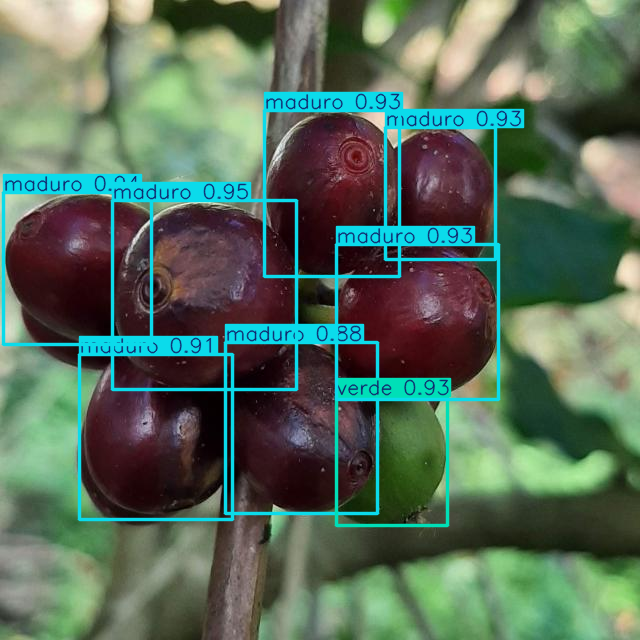

In [ ]:
import random
# Caminho da pasta de teste
test_folder = "/content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/test/images"

# Listar todas as imagens .jpg da pasta
images = [f for f in os.listdir(test_folder) if f.endswith(".jpg")]

# Sortear uma imagem aleatória
random_image = random.choice(images)
random_image_path = os.path.join(test_folder, random_image)

print(f"Imagem: {random_image_path}")

# Fazer predição
results = model.predict(source=random_image_path, conf=0.15, save=True)

# Exibir resultados
for r in results:
    r.show()

**Execução da Validação e Rastreamento dos Arquivos de Resultado**

Esta célula tem dupla função: executar a validação do modelo e identificar onde os resultados visuais foram salvos.

*   Validação (model.val): Executa o modo de validação do YOLO usando o arquivo de configuração data.yaml localizado no caminho do dataset definido. Os resultados dessa execução são armazenados na variável precisao.

*   Extração de Caminhos: Utiliza um bloco de segurança (try-except) para acessar a propriedade save_dir do objeto de resultados, que indica o diretório exato onde o YOLO salvou os gráficos. Em seguida, monta o caminho completo para o arquivo da imagem da Matriz de Confusão.

*   Exibição: Imprime os caminhos no console, facilitando para o usuário encontrar e baixar os arquivos de análise gerados automaticamente.

In [ ]:
DATASET_PATH = "/content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8"

precisao = model.val(data=os.path.join(DATASET_PATH, "data.yaml"))

try:
    results_dir = precisao.save_dir
    confusion_matrix_path = os.path.join(results_dir, "confusion_matrix.png")

    print("--------------------------------------------------")
    print(f"Pasta de Resultados (save_dir): {results_dir}")
    print(f"Caminho da Matriz de Confusão: {confusion_matrix_path}")
    print("--------------------------------------------------")

except NameError:
    print("A variável 'precisao' não foi definida. Rode a célula do 'model.val()' novamente.")

Ultralytics 8.3.232 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1218.8±344.5 MB/s, size: 47.6 KB)
val: Scanning /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/valid/labels.cache... 174 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 174/174 380.5Kit/s 0.0s
val: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/valid/images/IMG_20230824_102635_jpg.rf.36fd052eaf791c4cd6cb0f1a49adc05f.jpg: 1 duplicate labels removed
val: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/valid/images/IMG_20230824_102748_jpg.rf.8f5840c9ed38dff8aedbfc88a4874a70.jpg: 12 duplicate labels removed
val: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/valid/images/IMG_20230824_102912_jpg.rf.d83ce8e6dac1428a07e2b55475aa72a2.jpg: 5 duplicate labels removed
val: /content/dataset_novo/Coffee Fruit Maturity ---.v1i.yolov8/valid/images/IMG_20230824_102914_jpg.rf.e9d9b1b3368ec3c5b8497d3f8c491025.jpg: 8 duplic

**Exibição da Imagem da Matriz de Confusão**

Exibe visualmente o arquivo de imagem da Matriz de Confusão gerado durante a etapa de validação. O código implementa uma verificação de segurança (if os.path.exists) para confirmar se o arquivo realmente existe no caminho esperado (confusion_matrix_path) antes de tentar carregá-lo.

Se a imagem for encontrada, ela é renderizada diretamente no notebook utilizando as funções de exibição do IPython, com dimensões definidas para facilitar a análise. Se o arquivo não for encontrado, uma mensagem de erro informativa é exibida, orientando o usuário a verificar manualmente a estrutura de pastas dos resultados.

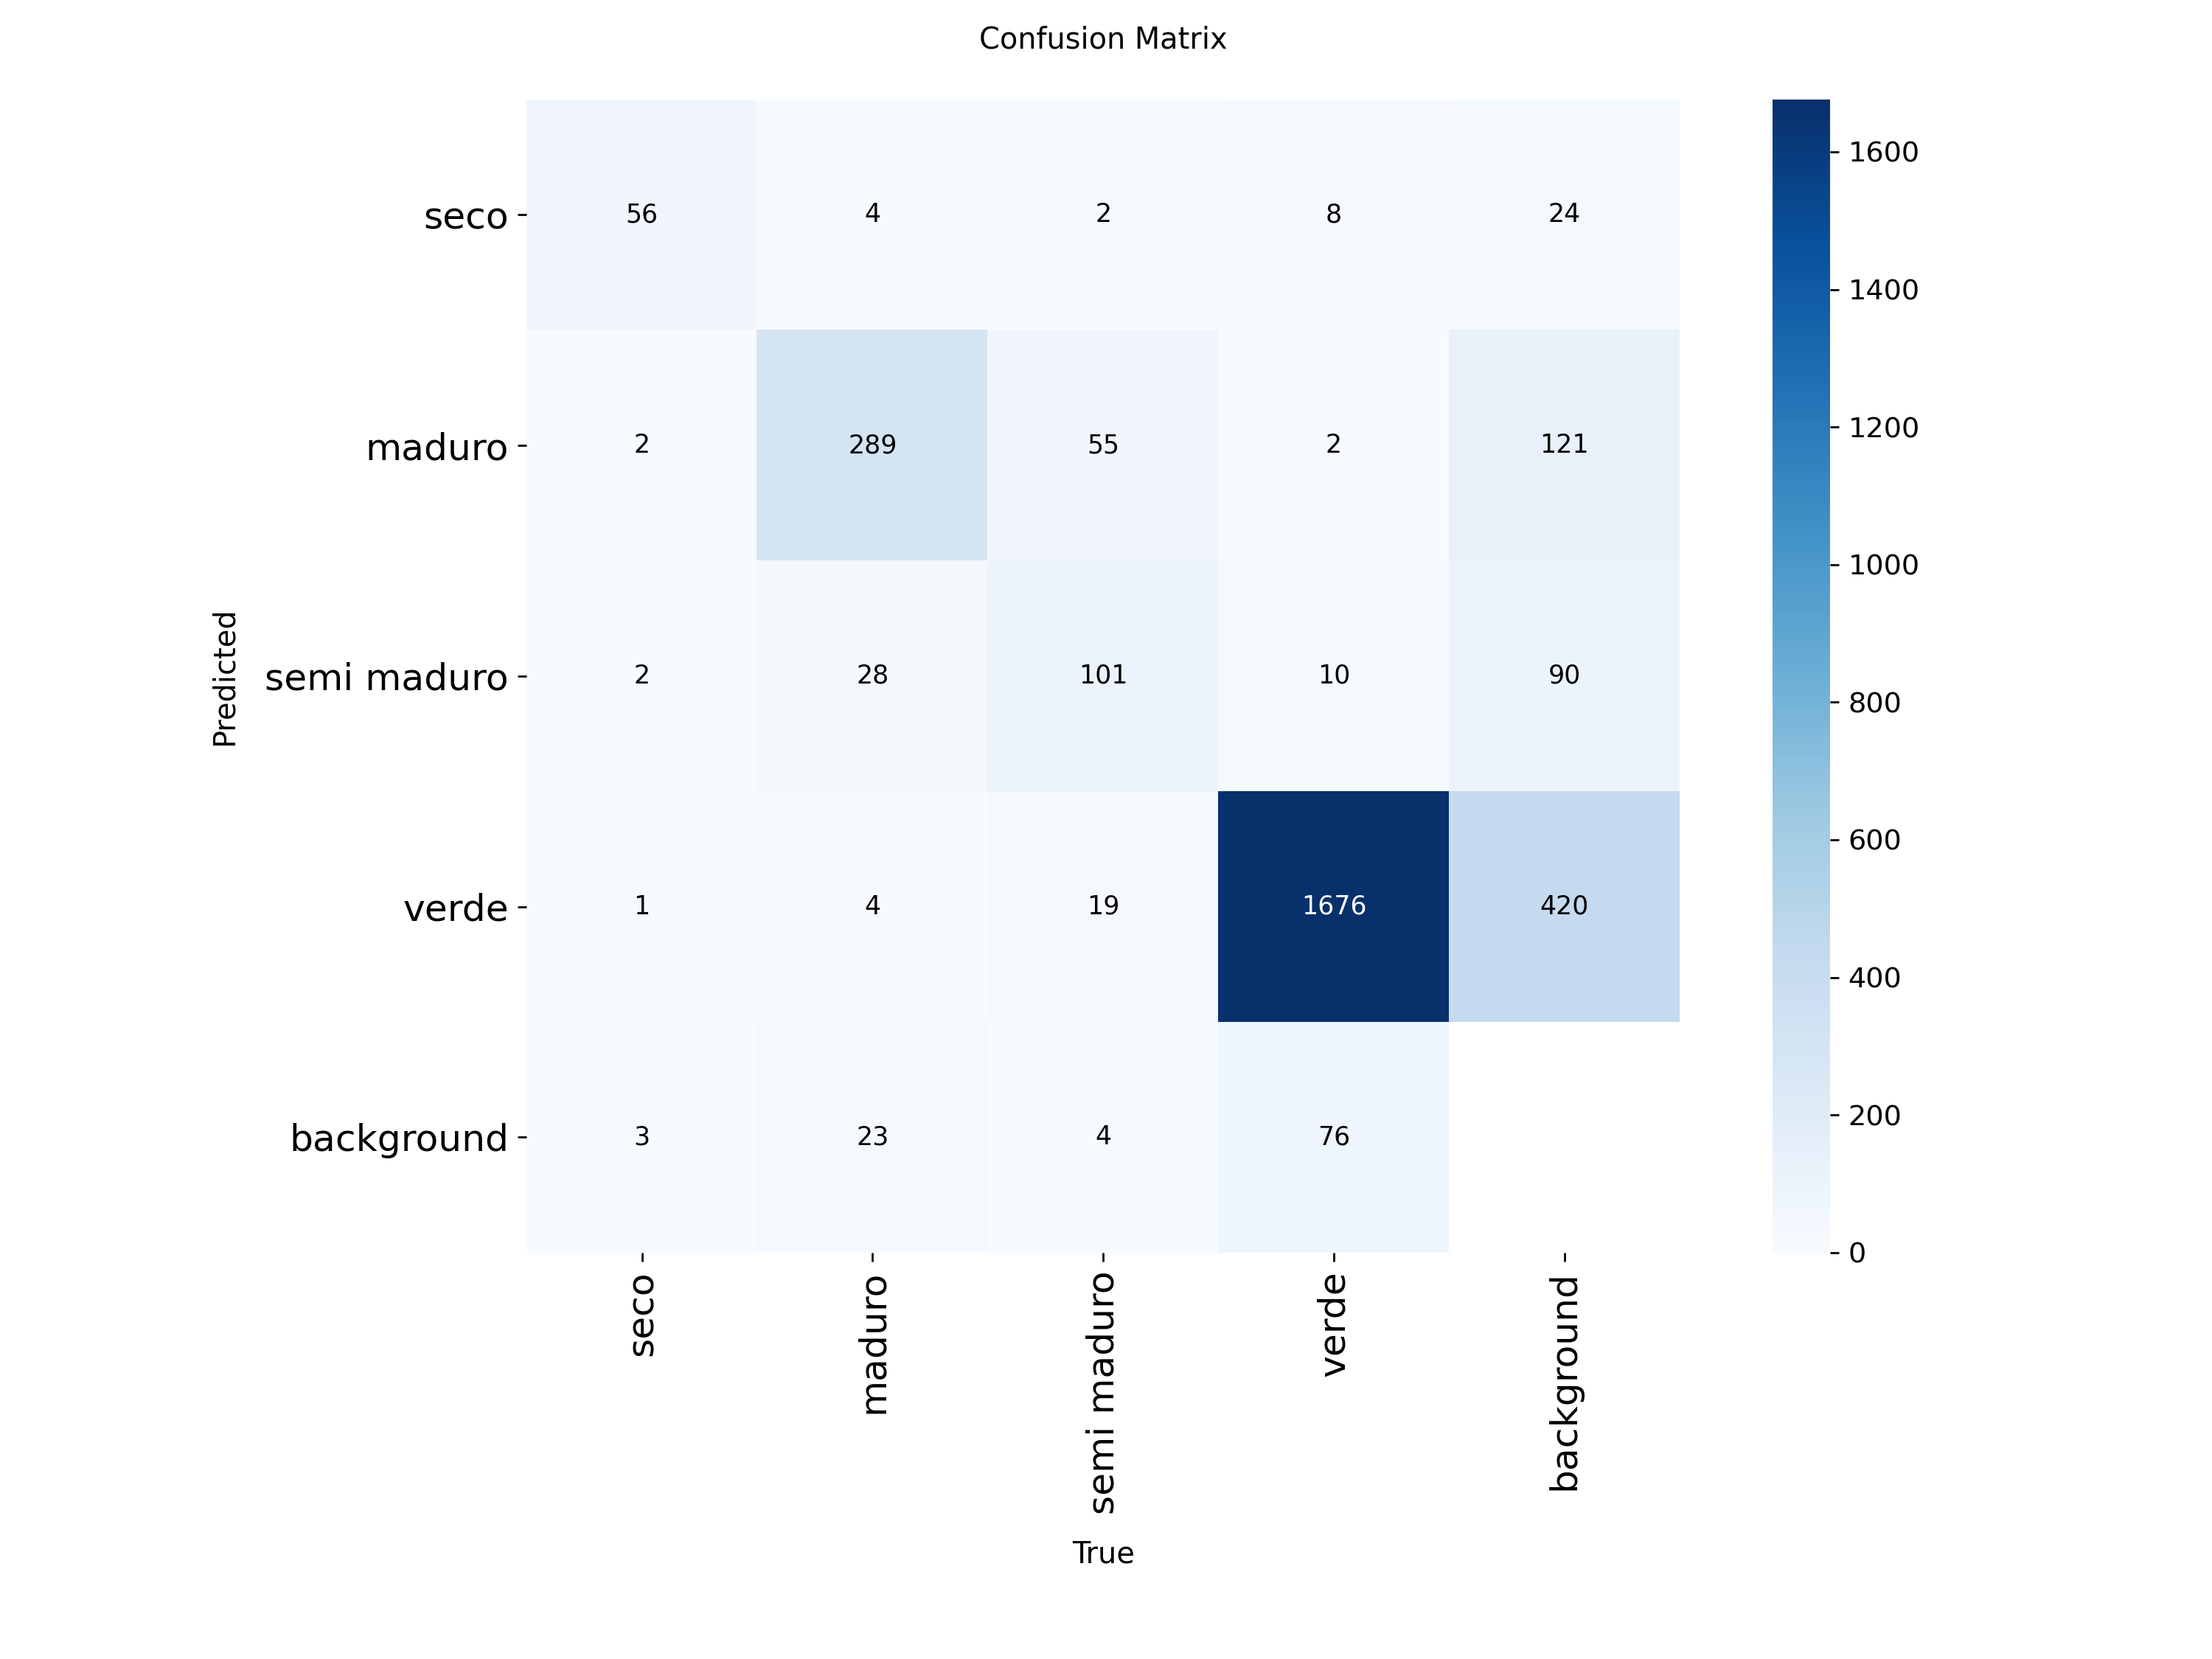

In [ ]:
from IPython.display import Image, display
import os

if os.path.exists(confusion_matrix_path):
    display(Image(filename=confusion_matrix_path, width=940, height=720))
else:
    print(f"ERRO: O arquivo da Matriz de Confusão não foi encontrado no caminho: {confusion_matrix_path}")
    print("Verifique no painel de arquivos (ícone de pasta) se a pasta 'runs/detect' existe e qual o nome da subpasta 'train'.")

**Extração e Exibição das Métricas de Precisão e Recall**

Precisão Média (mp): A média da precisão de todas as classes, indicando quão confiáveis são as detecções do modelo (evitando falsos positivos).

Recall Médio (mr): A média da revocação de todas as classes, indicando a capacidade do modelo de encontrar a maioria dos frutos presentes (evitando falsos negativos).

In [ ]:
print(f"Precisão Média (Average Precision): {precisao.box.mp}")
print(f"Recall Médio (Average Recall): {precisao.box.mr}")

Precisão Média (Average Precision): 0.7572033506830205
Recall Médio (Average Recall): 0.7859112746322313
